**Jakub Orchowski, s223281**

# Projekt 3 — Implementacja wybranych algorytmów grafiki komputerowej

## Cel projektu
Celem jest wygenerowanie obrazów i animacji przedstawiających trzy trójkąty 3D rzutowane równolegle na płaszczyznę OXY, oświetlone modelem Lamberta oraz modelem Phonga, z uwzględnieniem wzajemnych przecięć i rzucanych cieni.

## Opis zadania i analiza problemu

### Dane wejściowe
Trzy trójkąty o współrzędnych narożników:
- **Trójkąt A:** $(-22, 0, 58)$, $(11, 19, 58)$, $(0, 0, 26)$ — kolor bazowy $\varepsilon = (1, 0.5, 0.25)$
- **Trójkąt B:** $(-22, 0, 58)$, $(11, -19, 58)$, $(0, 0, 26)$ — kolor bazowy $\varepsilon = (0.25, 1, 0.5)$
- **Trójkąt C:** $(3, 19, 48)$, $(3, -19, 48)$, $(-8, 0, 16)$ — kolor bazowy $\varepsilon = (0.25, 0.5, 1)$

Rozdzielczość obrazu/animacji to $640 \times 480$, a rozmiar pojedynczego pixela to $0.1 \times 0.1$. Rzutowanie jest równoległe na płaszczyznę OXY.

### Geometria rzutowania
Rzutowanie równoległe na płaszczyznę OXY oznacza, że obserwator patrzy na scenę z góry wzdłuż osi OZ (promienie są równoległe do osi OZ, kierunek patrzenia to $-Z$). Źródło światła znajduje się pod trójkątami ($z = -28$), więc trójkąty są oświetlane od spodu. Widoczne na obrazach cienie powstają tam, gdzie bliższe źródłu światła trójkąty zasłaniają światło przed dalszymi.

### Oświetlenie
- Światło tła: $I_{amb} = [100, 100, 100]$
- Punktowe źródło światła: $I_{max} = [1000, 1000, 1000]$
- Spadek natężenia ze źródła punktowego: $\frac{I_{max}}{1 + 0.001 \cdot |p - p_{light}|^2}$

### Modele oświetlenia
**Lambert:**

$$I(p) = \varepsilon \cdot \left( I_{amb} + \frac{I_{max}}{1 + 0.001 \cdot |p - p_{light}|^2} \cdot \max(0, n \cdot l) \right)$$

**Phong** (z czynnikiem rozpraszającym $f(n,l) = \max(0, n \cdot l)$):

$$I(p) = \varepsilon \cdot \left( I_{amb} + \frac{I_{max}}{1 + 0.001 \cdot |p - p_{light}|^2} \cdot \max(0, n \cdot l) \cdot \left(1 + \max(0, r \cdot v)^m\right) \right)$$

gdzie $r = 2(n \cdot l)n - l$, $v$ to kierunek do oka obserwatora, a $m = 15$. Oko znajduje się w punkcie $(10, 5, 40)$.

### Cienie
Dla każdego punktu $p$ sprawdzamy, czy promień od źródła światła do $p$ przecina inny trójkąt w odległości mniejszej niż $|p - p_{light}|$ i po tej samej stronie co $p$. Jeśli tak — punkt znajduje się w cieniu i otrzymuje jedynie składową tła.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

%matplotlib inline

# --- STAŁE SCENY ---
W, H = 640, 480
PIXEL_SIZE = 0.1
CX, CY = W / 2, H / 2

I_AMB = np.array([100.0, 100.0, 100.0])
I_MAX = np.array([1000.0, 1000.0, 1000.0])
PLIGHT0 = np.array([-5.0, -5.0, -28.0])
EYE = np.array([10.0, 5.0, 40.0])
M_PHONG = 15

TRIANGLES = {
    'A': np.array([[-22, 0, 58], [11, 19, 58], [0, 0, 26]], dtype=float),
    'B': np.array([[-22, 0, 58], [11, -19, 58], [0, 0, 26]], dtype=float),
    'C': np.array([[3, 19, 48], [3, -19, 48], [-8, 0, 16]], dtype=float),
}

EPS = {
    'A': np.array([1.0, 0.5, 0.25]),
    'B': np.array([0.25, 1.0, 0.5]),
    'C': np.array([0.25, 0.5, 1.0]),
}

In [2]:
def triangle_normal(tri):
    """Wektor normalny trójkąta (znormalizowany)."""
    n = np.cross(tri[1] - tri[0], tri[2] - tri[0])
    return n / np.linalg.norm(n)


def point_in_triangle_2d(p, tri):
    """
    Test barycentryczny dla punktów p (N,2) i trójkąta tri (3,2).
    Zwraca tablicę boolowską o kształcie (N,).
    """
    A, B, C = tri[0], tri[1], tri[2]
    v0 = C - A
    v1 = B - A
    v2 = p - A
    dot00 = np.sum(v0 * v0)
    dot01 = np.sum(v0 * v1)
    dot02 = np.sum(v0 * v2, axis=1)
    dot11 = np.sum(v1 * v1)
    dot12 = np.sum(v1 * v2, axis=1)
    denom = dot00 * dot11 - dot01 * dot01
    u = (dot11 * dot02 - dot01 * dot12) / denom
    v = (dot00 * dot12 - dot01 * dot02) / denom
    return (u >= -1e-9) & (v >= -1e-9) & (u + v <= 1 + 1e-9)


def build_scene_grid():
    """
    Dla każdego pixela obrazu wyznacza identyfikator widocznego trójkąta,
    współrzędne 3D punktu na jego powierzchni oraz wektor normalny.
    Rzutowanie równoległe na OXY oznacza, że promień jest równoległy do osi OZ.
    """
    jj, ii = np.mgrid[0:H, 0:W]
    x = (ii + 0.5 - CX) * PIXEL_SIZE
    y = (CY - (jj + 0.5)) * PIXEL_SIZE
    xy = np.stack([x, y], axis=-1)
    flat_xy = xy.reshape(-1, 2)

    zbuf = np.full((H * W,), -np.inf)
    tri_id = np.full((H * W,), '', dtype=object)
    pts = np.zeros((H * W, 3))
    normals = np.zeros((H * W, 3))

    for name, tri in TRIANGLES.items():
        inside = point_in_triangle_2d(flat_xy, tri[:, :2])
        if not np.any(inside):
            continue
        # Równanie płaszczyzny trójkąta: z = a*x + b*y + c
        M = np.column_stack([tri[:, 0], tri[:, 1], np.ones(3)])
        abc = np.linalg.solve(M, tri[:, 2])
        z = abc[0] * x + abc[1] * y + abc[2]
        flat_z = z.ravel()
        update = inside & (flat_z > zbuf)
        zbuf[update] = flat_z[update]
        tri_id[update] = name
        pts[update, 0] = flat_xy[update, 0]
        pts[update, 1] = flat_xy[update, 1]
        pts[update, 2] = flat_z[update]
        normals[update] = triangle_normal(tri)

    return tri_id.reshape(H, W), pts.reshape(H, W, 3), normals.reshape(H, W, 3)


def ray_triangle_intersection_vec(o, d, tri):
    """
    Wektorowy algorytm Möllera–Trumbore'a dla wielu promieni (N,3)
    i jednego trójkąta (3,3). Zwraca parametr t oraz maskę trafień.
    """
    o = np.atleast_2d(o)
    d = np.atleast_2d(d)
    e1 = tri[1] - tri[0]
    e2 = tri[2] - tri[0]
    h = np.cross(d, e2[None, :])
    a = np.einsum('ij,j->i', h, e1)
    mask = np.abs(a) > 1e-8
    f = np.zeros_like(a)
    f[mask] = 1.0 / a[mask]
    s = o - tri[0][None, :]
    u = f * np.einsum('ij,ij->i', s, h)
    q = np.cross(s, e1[None, :])
    v = f * np.einsum('ij,ij->i', d, q)
    t = f * np.einsum('ij,ij->i', e2[None, :], q)
    valid = mask & (u >= 0) & (v >= 0) & (u + v <= 1)
    return t, valid


def render(tri_id, pts, normals, light_pos, model='lambert'):
    """
    Renderuje obraz 640x480 dla zadanego modelu oświetlenia.
    model może być 'lambert' lub 'phong'.
    """
    img = np.zeros((H, W, 3))
    for name, tri in TRIANGLES.items():
        mask = tri_id == name
        n_pixels = np.count_nonzero(mask)
        if n_pixels == 0:
            continue
        p = pts[mask]
        n = normals[mask]
        eps = EPS[name]

        # Składowa tła
        col = np.tile(eps * I_AMB, (n_pixels, 1))

        # Kierunek do źródła światła i odległość
        l_vec = light_pos - p
        d2 = np.einsum('ij,ij->i', l_vec, l_vec)
        d = np.sqrt(d2)
        l = l_vec / d[:, None]
        nl = np.maximum(np.einsum('ij,ij->i', n, l), 0)
        attenuation = 1.0 / (1.0 + 0.001 * d2)

        # Test cienia: czy inny trójkąt zasłania światło?
        in_shadow = np.zeros(n_pixels, dtype=bool)
        for other_name, other_tri in TRIANGLES.items():
            if other_name == name:
                continue
            dir_vec = p - light_pos[None, :]
            t, valid = ray_triangle_intersection_vec(
                np.broadcast_to(light_pos, (n_pixels, 3)), dir_vec, other_tri
            )
            in_shadow |= valid & (t > 1e-6) & (t < 1.0 - 1e-6)

        lit = ~in_shadow
        diffuse = eps * I_MAX * attenuation[:, None] * nl[:, None]
        col += diffuse * lit[:, None]

        if model == 'phong':
            r = 2 * nl[:, None] * n - l
            r = r / (np.linalg.norm(r, axis=1, keepdims=True) + 1e-12)
            v_vec = EYE - p
            v = v_vec / (np.linalg.norm(v_vec, axis=1, keepdims=True) + 1e-12)
            rv = np.maximum(np.einsum('ij,ij->i', r, v), 0)
            spec = eps * I_MAX * attenuation[:, None] * nl[:, None] * (rv ** M_PHONG)[:, None]
            col += spec * lit[:, None]

        img[mask] = col
    return np.clip(img, 0, 255).astype(np.uint8)


tri_id, pts, normals = build_scene_grid()
print(f'Liczba pokrytych pikseli: {np.sum(tri_id != "")}')
for name in TRIANGLES:
    print(f'{name}: {np.sum(tri_id == name)} pikseli')

Liczba pokrytych pikseli: 45216
A: 18536 pikseli
B: 18536 pikseli
C: 8144 pikseli


# Część I — Obrazy statyczne

## Zadanie 1. Model oświetlenia Lamberta

Generujemy obraz trójkątów oświetlonych światłem tła oraz punktowym źródłem światła położonym w $p_{light} = [-5, -5, -28]$.

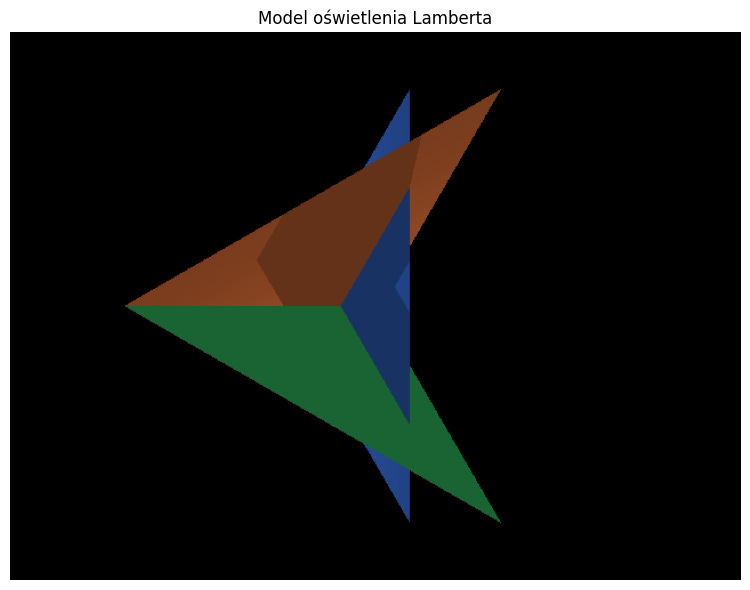

In [3]:
img_lambert = render(tri_id, pts, normals, PLIGHT0, model='lambert')

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img_lambert)
ax.set_title('Model oświetlenia Lamberta')
ax.axis('off')
plt.tight_layout()
plt.savefig('lambert.png', dpi=100)
plt.show()

### Wnioski
- W modelu Lamberta jasność każdego punktu zależy wyłącznie od kąta padania światła, a nie od położenia obserwatora.
- Widoczne są trzy trójkąty w kolorach bazowych RGB, częściowo zasłaniające się nawzajem.
- Cienie rzucane przez trójkąt C na A i B oraz przez A/B na siebie są widoczne jako ciemniejsze obszary oświetlone jedynie światłem tła.

## Zadanie 2. Model oświetlenia Phonga

Parametry: oko obserwatora w $[10, 5, 40]$, współczynnik $m = 15$.

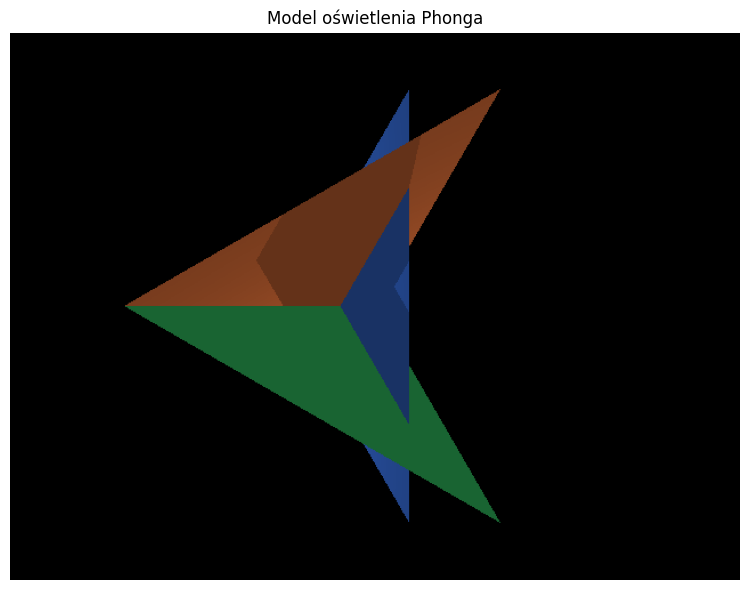

In [4]:
img_phong = render(tri_id, pts, normals, PLIGHT0, model='phong')

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img_phong)
ax.set_title('Model oświetlenia Phonga')
ax.axis('off')
plt.tight_layout()
plt.savefig('phong.png', dpi=100)
plt.show()

### Wnioski
- Model Phonga dodaje do rozpraszania Lamberta składową zwierciadlaną, co widoczne jest jako jaśniejsze refleksy na powierzchniach.
- Położenie oka ma wpływ na to, gdzie pojawiają się odblaski.
- Cienie pozostają identyczne jak w modelu Lamberta, ponieważ zależą tylko od geometrii sceny i położenia źródła światła.

# Część II — Animacje

## Zadanie 3. Animacja z modelem Lamberta

Źródło światła porusza się po okręgu zgodnie z równaniami:

$$x(t_k) = -5\cos(t_k), \quad y(t_k) = -5 + 5\sin(t_k), \quad z(t_k) = -28, \quad t_k = 0.0315 \cdot k$$

gdzie $k$ to numer klatki. Animacja składa się z 200 klatek.

Zapisano anim_lambert.avi


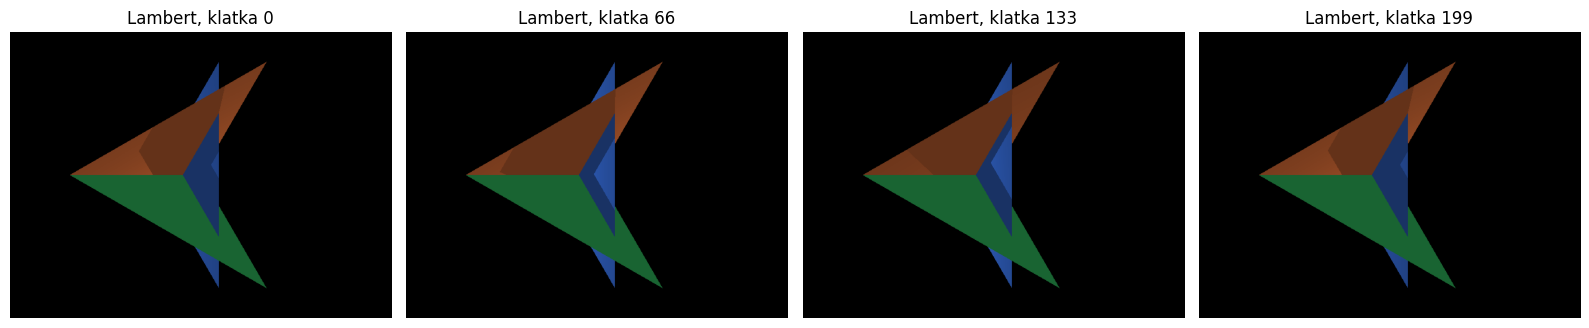

In [5]:
def generate_animation(model, n_frames=200):
    """Generuje animację 640x480 o zadanej liczbie klatek."""
    frames = []
    for k in range(n_frames):
        tk = 0.0315 * k
        light_pos = np.array([-5 * np.cos(tk), -5 + 5 * np.sin(tk), -28.0])
        frames.append(render(tri_id, pts, normals, light_pos, model))
    return np.stack(frames, axis=0)


frames_lambert = generate_animation('lambert', n_frames=200)
iio.imwrite('anim_lambert.avi', frames_lambert, extension='.avi')
print('Zapisano anim_lambert.avi')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, [0, 66, 133, 199]):
    ax.imshow(frames_lambert[idx])
    ax.set_title(f'Lambert, klatka {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Wnioski
- Ruchome źródło światła powoduje zmianę oświetlenia i położenia cieni na powierzchniach trójkątów.
- Ponieważ geometria sceny jest stała, maski trójkątów i ich normalne obliczone są jednorazowo; w każdej klatce zmienia się jedynie położenie światła i na jego podstawie oświetlenie oraz cienie.
- Dzięki tej optymalizacja animacja 200 klatek generuje się w kilka sekund.

## Zadanie 4. Animacja z modelem Phonga

Te same parametry ruchu źródła światła, ale z wykorzystaniem modelu oświetlenia Phonga.

Zapisano anim_phong.avi


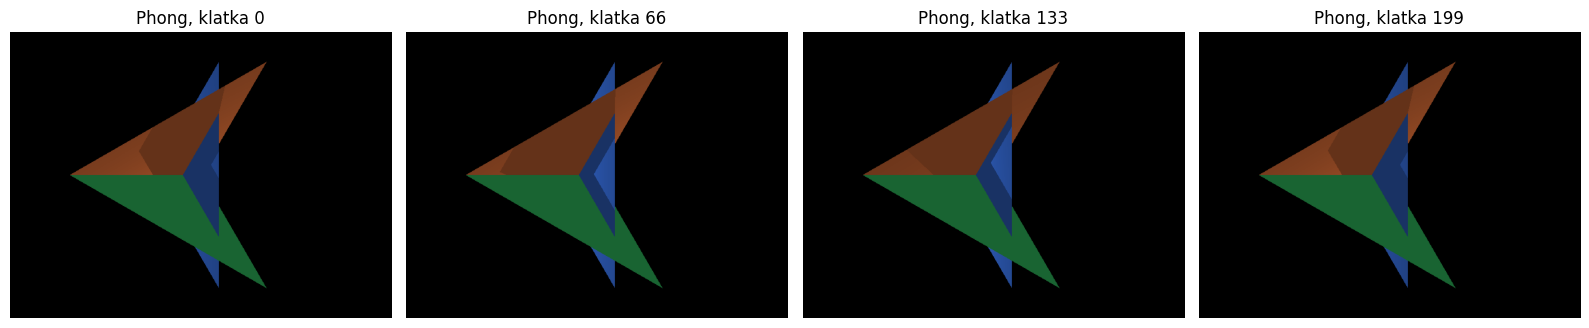

In [6]:
frames_phong = generate_animation('phong', n_frames=200)
iio.imwrite('anim_phong.avi', frames_phong, extension='.avi')
print('Zapisano anim_phong.avi')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, [0, 66, 133, 199]):
    ax.imshow(frames_phong[idx])
    ax.set_title(f'Phong, klatka {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Wnioski
- W modelu Phonga ruch źródła światła zmienia zarówno rozpraszającą, jak i zwierciadlaną składową oświetlenia.
- Refleksy są związane z kierunkiem do oka obserwatora, dlatego ich położenie na powierzchniach zmienia się subtelnie wraz z ruchem światła.
- Animacja zachowuje płynność i poprawną obsługę cieni.

## Wersja 20-klatkowa do szybkiej weryfikacji

Zgodnie z uwagą w treści projektu, tworzymy również krótkie wersje wideo z pierwszych 20 klatek.

In [7]:
iio.imwrite('anim_lambert_20.avi', frames_lambert[:20], extension='.avi')
iio.imwrite('anim_phong_20.avi', frames_phong[:20], extension='.avi')
print('Zapisano skrócone animacje: anim_lambert_20.avi, anim_phong_20.avi')
print(f'Pełna animacja Lamberta: {frames_lambert.shape[0]} klatek')
print(f'Pełna animacja Phonga:   {frames_phong.shape[0]} klatek')

Zapisano skrócone animacje: anim_lambert_20.avi, anim_phong_20.avi
Pełna animacja Lamberta: 200 klatek
Pełna animacja Phonga:   200 klatek


# Instrukcja uruchomienia

1. Otwórz notebook `proj3.ipynb` w Jupyter Notebook/Lab.
2. Uruchom wszystkie komórki kolejno od góry (`Run All`).
3. Wymagane pakiety (dostępne w `pyproject.toml`): `numpy`, `matplotlib`, `imageio`.
4. Zalecane uruchomienie przez menedżer `uv`:
   ```bash
   uv run jupyter notebook proj3.ipynb
   ```
5. Wyniki:
   - Obrazy: `lambert.png`, `phong.png`
   - Animacje pełne: `anim_lambert.avi`, `anim_phong.avi` (po 200 klatek)
   - Animacje skrócone: `anim_lambert_20.avi`, `anim_phong_20.avi`